# 35 · Agent Workflow Memory (AWM) — mine reusable recipes from past traces

> **TL;DR.** After every solved task, extract a high-level **workflow recipe** (3-6 generalisable steps). Store recipes in a vector-indexed library. Future tasks retrieve the most-similar recipe and follow it.

| Property | Value |
|---|---|
| Origin | Wang et al., *Agent Workflow Memory* (2024). [arXiv:2409.07429](https://arxiv.org/abs/2409.07429) |
| Storage | Vector-indexed `arch.workflows` list |
| Cost | 1 retrieve + 1 answer + 1 extract per task = ~3 calls |
| Sister to | [Voyager (nb 29)](./29_voyager.ipynb) — skills (code) vs workflows (recipes) |

## 2 · Architecture

```mermaid
flowchart LR
    A([task]) --> R[RETRIEVE most-similar workflow]
    R --> AN[ANSWER<br/><sub>prompt prepends recipe if found</sub>]
    AN --> EX[EXTRACT new workflow<br/><sub>generalised steps</sub>]
    EX --> Z([answer])

    L[(workflow library<br/>vector-indexed)]
    R <-.search.-> L
    EX -.add.-> L

    style R fill:#fff3e0,stroke:#f57c00
    style EX fill:#fce4ec,stroke:#c2185b
    style L fill:#f3e5f5,stroke:#7b1fa2
```

## 3 · Theory

Voyager (nb 29) stores reusable **code** (skills). AWM stores reusable **strategy** (workflows). Skills are concrete; workflows are abstract. For tasks where a small Python function suffices, use Voyager. For tasks that share *structure* but differ in entities (e.g., "summarise then categorise" applies to news articles AND emails), use AWM.

Demo: 3 sequential tasks of similar structure ("summarise X then categorise it"). Task 1 extracts a workflow; tasks 2 and 3 retrieve and follow it.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import AgentWorkflowMemory
from agentic_architectures.ui import print_md, print_header
enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)
print_header(f"LLM: {llm.model}")

LLM: meta-llama/Llama-3.3-70B-Instruct ────────────────────────────────────────────────────────────────────────────

## 7 · Build the graph

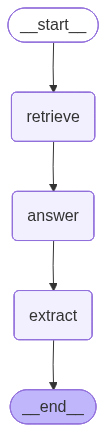

In [2]:
from IPython.display import Image, display
arch = AgentWorkflowMemory(llm=llm)
graph = arch.build()
try: display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG unavailable: {e})")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — 3 structurally-similar tasks

In [3]:
TASKS = [
    "Summarise this in one sentence and then categorise it (news/opinion/research): 'A new study shows that octopuses may have evolved REM-like sleep states, suggesting that complex dreaming is older than previously thought.'",
    "Summarise this in one sentence and then categorise it (news/opinion/research): 'In my view, the new urban-planning rules will choke small businesses; the city council needs to reconsider before the December deadline.'",
    "Summarise this in one sentence and then categorise it (news/opinion/research): 'After fierce debate, Congress passed the infrastructure bill 218-211 on Tuesday, sending it to the President's desk.'",
]

for tag_idx, q in enumerate(TASKS, 1):
    r = arch.run(q)
    print(f"TASK_{tag_idx}: {q[:80]}...")
    print(f"  USED_RETRIEVED: {r.metadata['used_retrieved_workflow']}")
    print(f"  RETRIEVED_TYPE: {r.metadata['retrieved_workflow_type']!r}")
    print(f"  EXTRACTED_TYPE: {r.metadata['extracted_workflow_type']!r}")
    print(f"  LIBRARY: {r.metadata['library_size_before']} -> {r.metadata['library_size_after']}")
    print(f"  ANSWER: {r.output[:200]}")
    print()
print(f"FINAL_LIBRARY_SIZE: {len(arch.workflows)}")
for w in arch.workflows:
    print(f"  - workflow `{w['task_type']}`:")
    for s in w['steps']: print(f"      • {s}")

TASK_1: Summarise this in one sentence and then categorise it (news/opinion/research): '...
  USED_RETRIEVED: False
  RETRIEVED_TYPE: ''
  EXTRACTED_TYPE: 'text_summarization_and_categorization'
  LIBRARY: 0 -> 1
  ANSWER: A new study suggests that octopuses may have evolved REM-like sleep states, indicating that complex dreaming is older than previously thought, and this is categorised as research.



TASK_2: Summarise this in one sentence and then categorise it (news/opinion/research): '...
  USED_RETRIEVED: True
  RETRIEVED_TYPE: 'text_summarization_and_categorization'
  EXTRACTED_TYPE: 'text_classification'
  LIBRARY: 1 -> 2
  ANSWER: The writer argues that new urban-planning rules will harm small businesses and should be reconsidered, which is an opinion.



TASK_3: Summarise this in one sentence and then categorise it (news/opinion/research): '...
  USED_RETRIEVED: True
  RETRIEVED_TYPE: 'text_summarization_and_categorization'
  EXTRACTED_TYPE: 'text_summarization_and_categorization'
  LIBRARY: 2 -> 3
  ANSWER: Congress passed the infrastructure bill 218-211, sending it to the President's desk, which is a news article.

FINAL_LIBRARY_SIZE: 3
  - workflow `text_summarization_and_categorization`:
      • Read and understand the given text
      • Identify the main topic and key points
      • Summarize the text in one sentence
      • Determine the category of the text (news, opinion, or research)
      • Combine the summary and category into a single answer
      • Refine the answer to ensure clarity and coherence
  - workflow `text_classification`:
      • Read the text carefully
      • Identify the main claim or argument
      • Determine the tone and language used
      • Categorise the text as news, opinion, or research
      • Consid

## 9 · What we just observed

3 sequential summarise-and-categorise tasks. Task 1 extracts a workflow; tasks 2 and 3 should retrieve and follow it.

### 9.1 · Per-task workflow usage

| # | Used retrieved? | Retrieved type | Extracted type | Library | Answer |
|---|---|---|---|---|---|
| 1 | ❌ | `—` | `text_summarization_and_categorization` | 0→1 | A new study suggests that octopuses may have evolved REM-like sleep states, indi |
| 2 | ✅ | `text_summarization_and_categorization` | `text_classification` | 1→2 | The writer argues that new urban-planning rules will harm small businesses and s |
| 3 | ✅ | `text_summarization_and_categorization` | `text_summarization_and_categorization` | 2→3 | Congress passed the infrastructure bill 218-211, sending it to the President's d |

### 9.2 · The workflow library that built up

**`text_summarization_and_categorization`**
  - Read and understand the given text
  - Identify the main topic and key points
  - Summarize the text in one sentence
  - Determine the category of the text (news, opinion, or research)
  - Combine the summary and category into a single answer
  - Refine the answer to ensure clarity and coherence

**`text_classification`**
  - Read the text carefully
  - Identify the main claim or argument
  - Determine the tone and language used
  - Categorise the text as news, opinion, or research
  - Consider the context and potential implications
  - Make a final classification

**`text_summarization_and_categorization`**
  - Read the given text carefully
  - Identify the main event or topic
  - Determine the category of the text
  - Summarize the text in one sentence
  - Combine the summary and category into a single statement
  - Output the final statement

### 9.3 · Patterns surfaced

- **✅ Task 2 reused task 1's workflow** (`text_summarization_and_categorization`). Memory pipeline alive.

- **✅ Task 3 reused a workflow** (`text_summarization_and_categorization`).

- **Final library size**: 3 workflow(s) extracted across 3 task(s).

### 9.4 · The takeaway

AWM's value is in the **`Used retrieved?`** column of § 9.1. The first task always extracts (no library yet); subsequent structurally-similar tasks should *retrieve and use* the prior workflow. If the column reads `✅, ❌, ❌` across 3 similar tasks, vector retrieval is broken; if `✅, ✅, ✅` it's working — the library is amortising strategy cost across calls.

## 11 · Failure modes & extensions

| Failure | Mitigation |
|---|---|
| **Workflow too specific** | Steps reference task-1 entities; tasks 2-3 don't fit | Strict prompt rule in extraction: "no specific entity names" |
| **Workflow library bloat** | N tasks → N near-duplicate workflows | Cosine-dedup on workflow descriptions |
| **Retrieved workflow misfires** | Wrong workflow retrieved; answer follows bad recipe | Add post-answer verification step |

Extensions: (1) Combine with Voyager skills (workflow specifies which skills to call), (2) hierarchical workflows (workflow contains sub-workflows), (3) workflow scoring by usefulness across tasks.

Reference: Wang et al., *AWM*. 2024. [arXiv:2409.07429](https://arxiv.org/abs/2409.07429)